--- 1. Loading and Filtering Data ---
Dropped 450 rows (BI-RADS 3 or missing). Remaining: 2793
Filtered for Mass cases only. Remaining: 1335

--- 2. Patient-Level Stratified Splitting ---

--- 3. Validating Leakage (Assertion Block) ---
SUCCESS: Zero patient overlap detected across splits.

--- 4. Final Data Statistics ---
Pathology      BENIGN  MALIGNANT  Total
Patient_Split                          
Test              121        140    261
Train             431        514    945
Val                58         71    129

--- 5. Visualizing 16-bit Triplet Alignment (FULL | ROI | CROP) ---


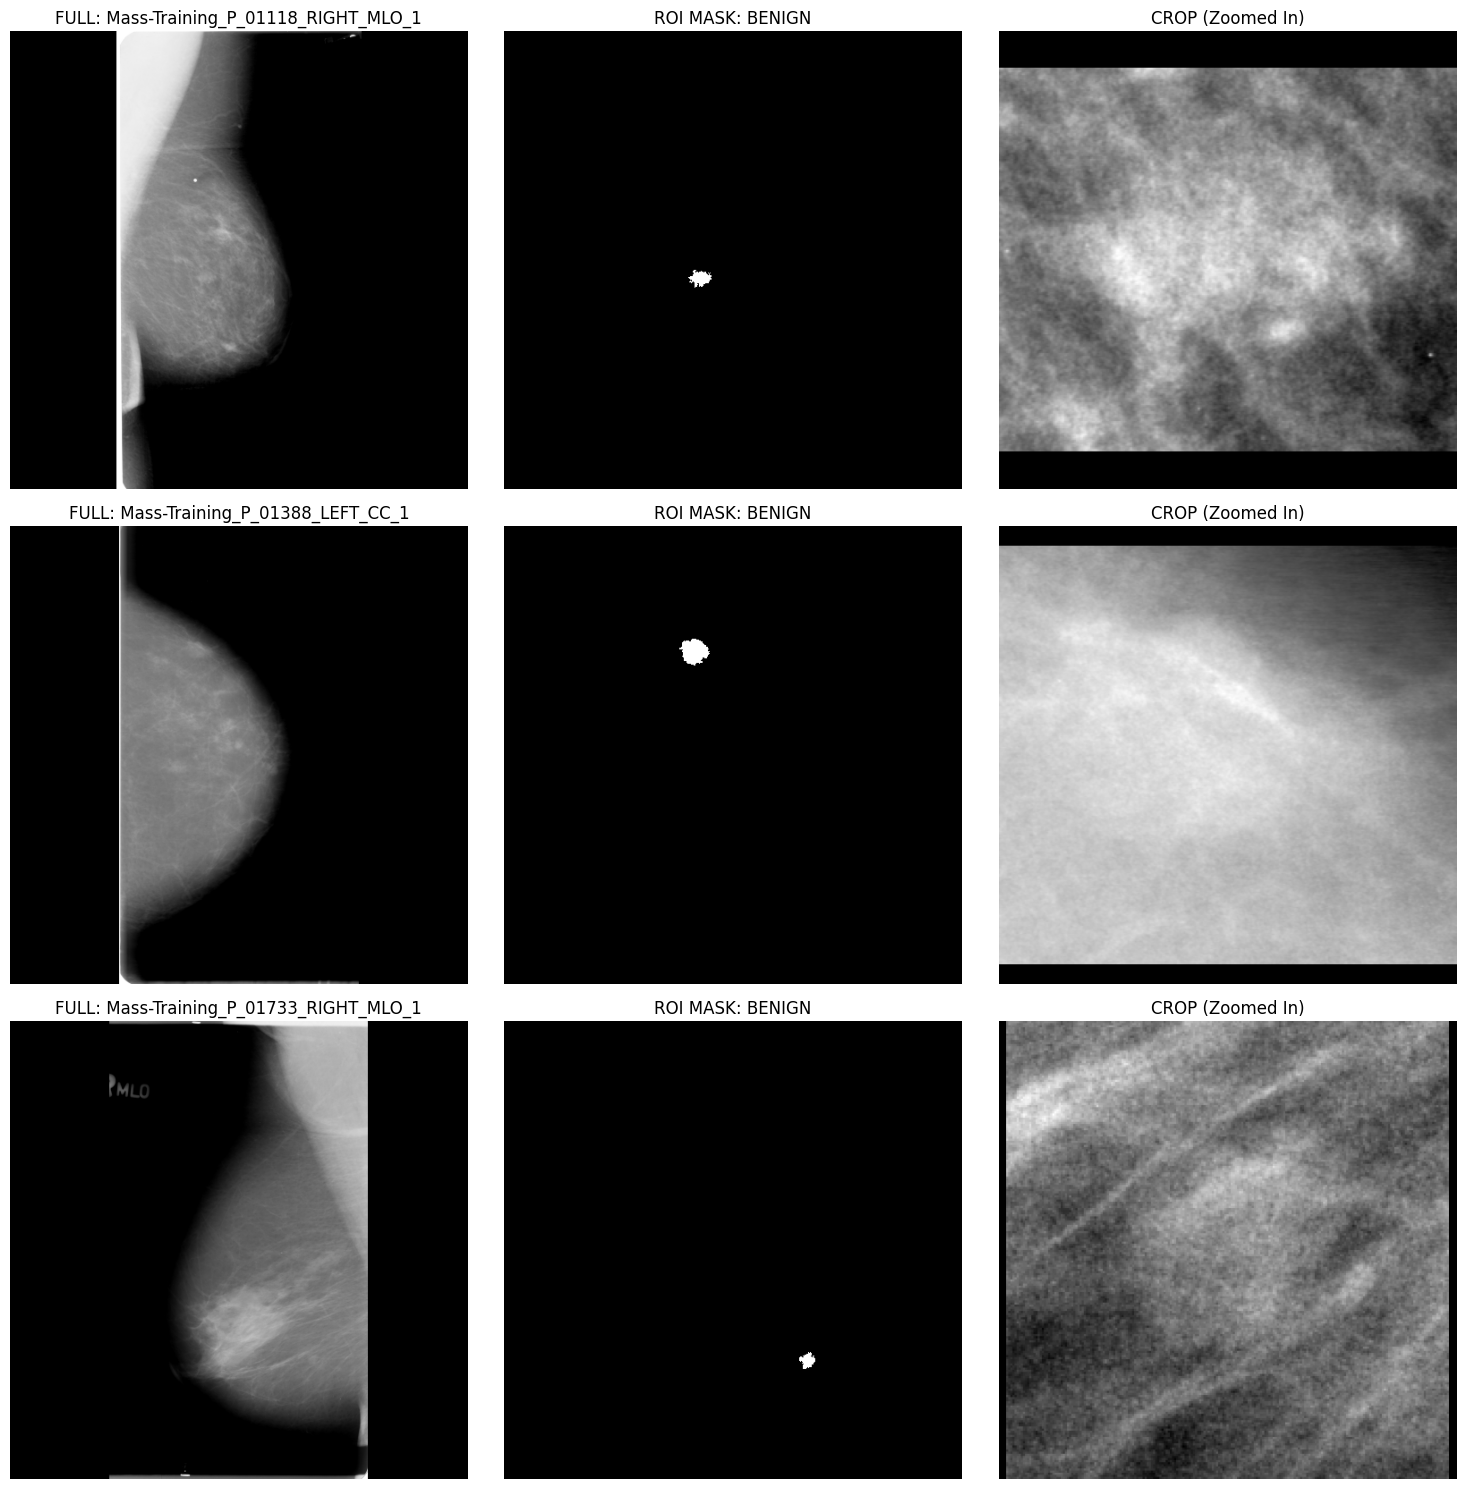


Saved clean dataset to: CBIS_Master_Index_Clean.csv


In [1]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- Configuration (Kaggle Paths) ---
DATA_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1"
KAGGLE_CSV_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/metdatakagglegrad/Kaggle_CSVs"
MASTER_CSV_PATH = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS_Master_Index.csv"
RANDOM_SEED = 42

def load_and_extract_birads():
    csv_files = [
        "mass_case_description_train_set.csv",
        "mass_case_description_test_set.csv",
        "calc_case_description_train_set.csv",
        "calc_case_description_test_set.csv"
    ]

    combined_df = pd.DataFrame()
    for file in csv_files:
        path = os.path.join(KAGGLE_CSV_DIR, file)
        if os.path.exists(path):
            df = pd.read_csv(path)
            combined_df = pd.concat([combined_df, df], ignore_index=True)

    def get_case_id(path):
        return str(path).split('/')[0].strip()

    combined_df['Case_ID'] = combined_df['image file path'].apply(get_case_id)
    return dict(zip(combined_df['Case_ID'], combined_df['assessment']))

def match_birads(patient_id, birads_map):
    if patient_id in birads_map:
        return birads_map[patient_id]
    base = re.sub(r'_\d+$', '', patient_id)
    if base in birads_map:
        return birads_map[base]
    return None

def main():
    print("--- 1. Loading and Filtering Data ---")
    df = pd.read_csv(MASTER_CSV_PATH)
    initial_count = len(df)
    
    birads_map = load_and_extract_birads()
    df['BI_RADS'] = df['PatientID'].apply(lambda pid: match_birads(pid, birads_map))
    df = df[df['BI_RADS'].notna() & (df['BI_RADS'] != 3)].copy()
    print(f"Dropped {initial_count - len(df)} rows (BI-RADS 3 or missing). Remaining: {len(df)}")
    
    # --- NEW: Mass-only filter ---
    df = df[df['PatientID'].str.contains("Mass", case=False, na=False)].copy()
    print(f"Filtered for Mass cases only. Remaining: {len(df)}")
    # -----------------------------
    
    df['Label'] = df['Pathology'].map({'MALIGNANT': 1, 'BENIGN': 0})
    df['True_Patient_ID'] = df['PatientID'].apply(lambda x: re.search(r'(P_\d+)', x).group(1))

    print("\n--- 2. Patient-Level Stratified Splitting ---")
    patient_df = df.groupby('True_Patient_ID')['Label'].max().reset_index()
    patient_df.columns = ['True_Patient_ID', 'Patient_Label']
    
    train_patients, temp_patients, _, temp_labels = train_test_split(
        patient_df['True_Patient_ID'], patient_df['Patient_Label'],
        test_size=0.30, random_state=RANDOM_SEED, stratify=patient_df['Patient_Label']
    )
    
    val_patients, test_patients = train_test_split(
        temp_patients, test_size=(2/3), random_state=RANDOM_SEED, stratify=temp_labels
    )
    
    train_set, val_set, test_set = set(train_patients), set(val_patients), set(test_patients)

    def assign_split(pid):
        if pid in train_set: return 'Train'
        if pid in val_set: return 'Val'
        return 'Test'

    df['Patient_Split'] = df['True_Patient_ID'].apply(assign_split)
    df.drop(columns=['Split'], inplace=True)

    print("\n--- 3. Validating Leakage (Assertion Block) ---")
    assert len(train_set.intersection(val_set)) == 0, "LEAKAGE DETECTED: Train and Val"
    assert len(train_set.intersection(test_set)) == 0, "LEAKAGE DETECTED: Train and Test"
    assert len(val_set.intersection(test_set)) == 0, "LEAKAGE DETECTED: Val and Test"
    print("SUCCESS: Zero patient overlap detected across splits.")

    print("\n--- 4. Final Data Statistics ---")
    stats = pd.crosstab(df['Patient_Split'], df['Pathology'])
    stats['Total'] = stats.sum(axis=1)
    print(stats[['BENIGN', 'MALIGNANT', 'Total']])

    print("\n--- 5. Visualizing 16-bit Triplet Alignment (FULL | ROI | CROP) ---")
    
    sample_df = df.sample(3, random_state=RANDOM_SEED)
    # CHANGED: 3 columns instead of 2 for the subplot
    fig, axes = plt.subplots(3, 3, figsize=(15, 15)) 

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        full_path = os.path.join(DATA_DIR, row['Full_Path'])
        roi_path = os.path.join(DATA_DIR, row['ROI_Path'])
        crop_path = os.path.join(DATA_DIR, row['Crop_Path']) # Added crop path
        
        full_img = cv2.imread(full_path, cv2.IMREAD_UNCHANGED)
        roi_img = cv2.imread(roi_path, cv2.IMREAD_UNCHANGED)
        crop_img = cv2.imread(crop_path, cv2.IMREAD_UNCHANGED) # Added crop load
        
        # 16-bit Matplotlib scaling
        full_display = full_img.astype(np.float32) / 65535.0
        roi_display = roi_img.astype(np.float32) / np.max(roi_img) if np.max(roi_img) > 0 else roi_img
        crop_display = crop_img.astype(np.float32) / 65535.0 # Added crop scaling

        # Panel 1: Full
        axes[idx, 0].imshow(full_display, cmap='gray')
        axes[idx, 0].set_title(f"FULL: {row['PatientID']}")
        axes[idx, 0].axis('off')
        
        # Panel 2: ROI Mask
        axes[idx, 1].imshow(roi_display, cmap='gray')
        axes[idx, 1].set_title(f"ROI MASK: {row['Pathology']}")
        axes[idx, 1].axis('off')
        
        # Panel 3: Crop
        axes[idx, 2].imshow(crop_display, cmap='gray')
        axes[idx, 2].set_title(f"CROP (Zoomed In)")
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.show()

    # Save final CSV
    out_csv = "CBIS_Master_Index_Clean.csv"
    df.to_csv(out_csv, index=False)
    print(f"\nSaved clean dataset to: {out_csv}")

if __name__ == "__main__":
    main()

In [2]:
!pip install monai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.0 MB/s eta 0:00:00a 0:00:01


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-26 13:57:10.783855: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777211830.983254      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777211831.045036      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777211831.524584      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777211831.524630      55 computation_placer.cc:1

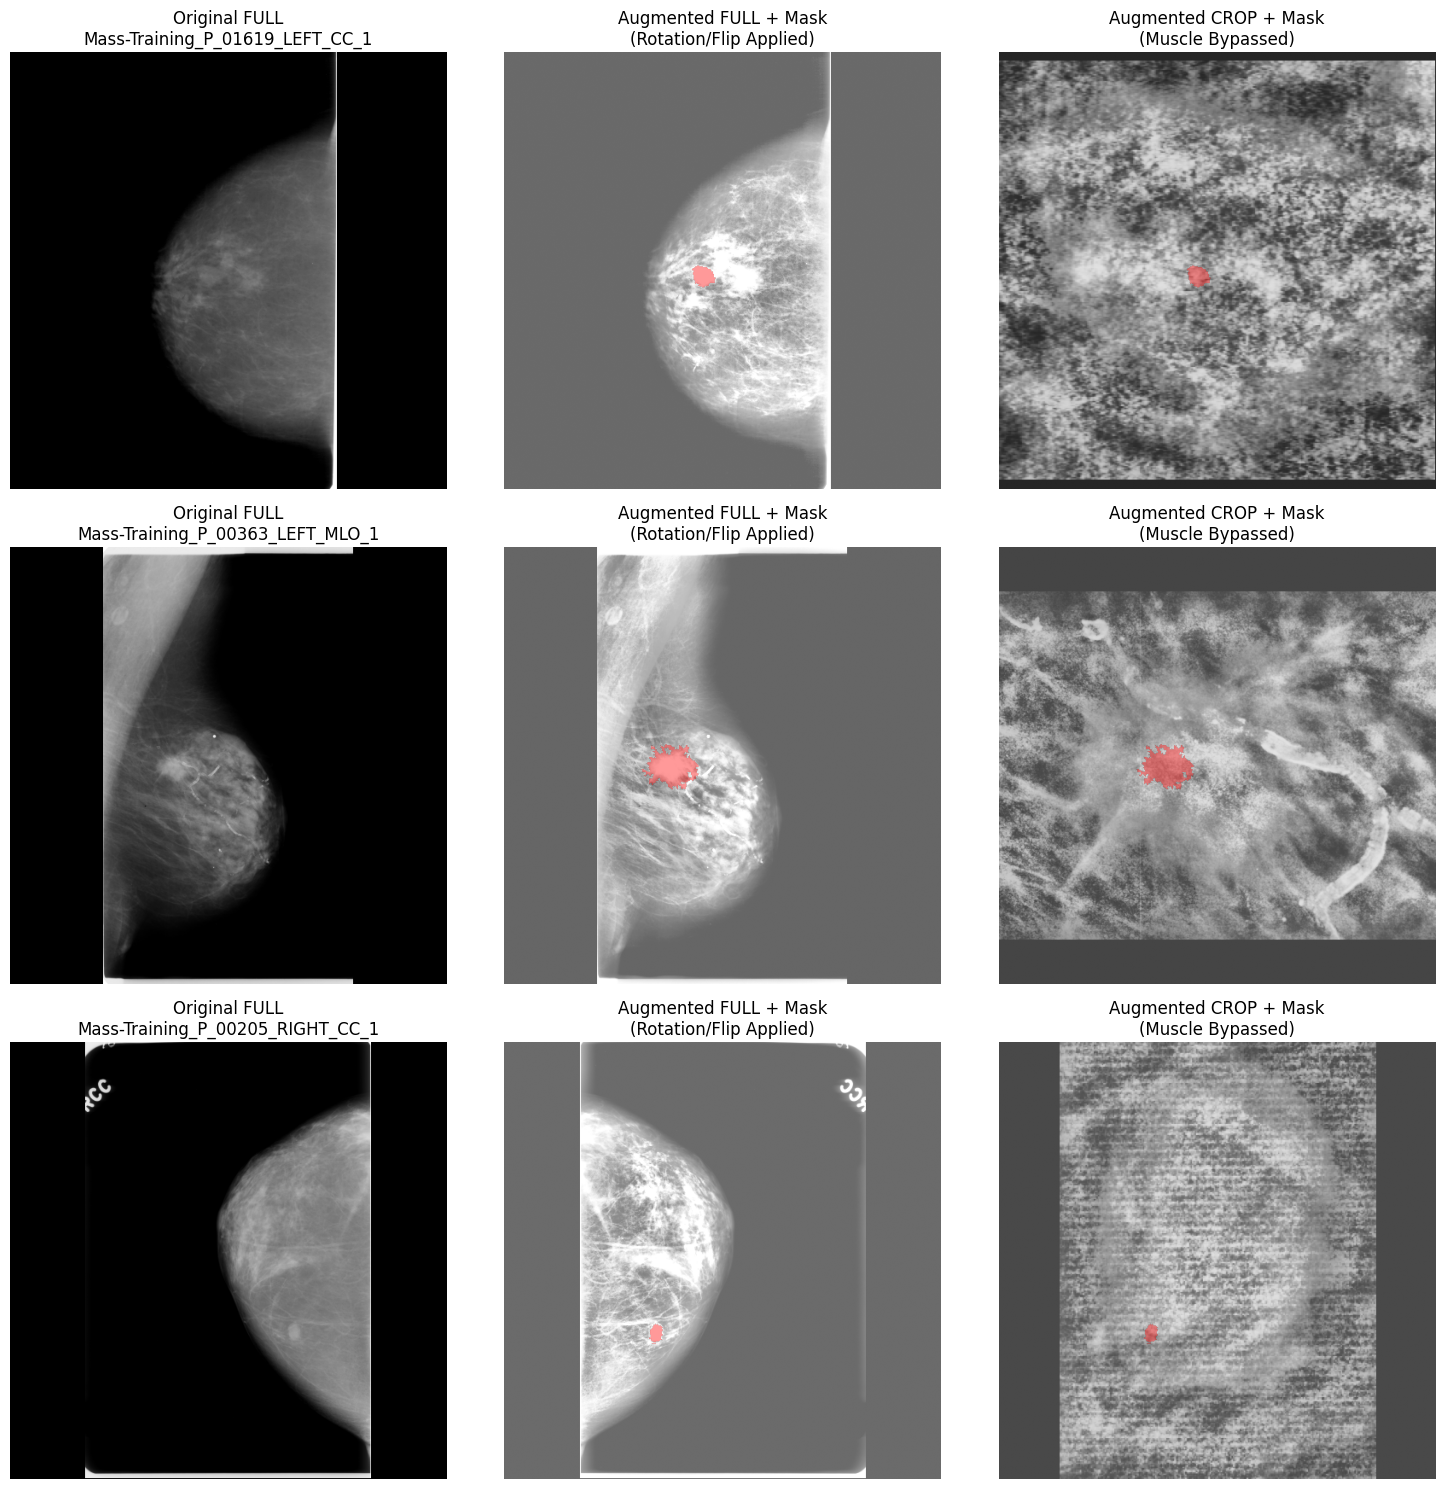

In [3]:
import os
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from monai.transforms import MapTransform, Compose, EnsureChannelFirstd, RandFlipd, RandRotated

# --- Configuration ---
DATA_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1" 
CSV_PATH = "CBIS_Master_Index_Clean.csv"      
RANDOM_SEED = 42

# ==============================================================================
# 1. Custom MONAI Dictionary Transforms
# ==============================================================================

class ConditionalFlipd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        patient_id = d[self.id_key]
        if "_RIGHT_" in patient_id:
            for key in self.keys:
                d[key] = cv2.flip(d[key], 1)
        return d

class PectoralRemovalMLOd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        patient_id = d[self.id_key]
        
        for key in self.keys:
            img = d[key]
            
            # AUTOMATIC BYPASS: CC views or images smaller than 1500px (Crops)
            if "_CC_" in patient_id or img.shape[0] < 1500:
                continue
                
            img_8u = (img / 256).astype(np.uint8)
            _, binary = cv2.threshold(img_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            
            h, w = binary.shape
            flood_mask = np.zeros((h + 2, w + 2), np.uint8)
            cv2.floodFill(binary, flood_mask, (0, 0), 255)
            
            pectoral_region = flood_mask[1:-1, 1:-1]
            d[key] = np.where(pectoral_region == 1, 0, img)
            
        return d

class CLAHE16Bitd(MapTransform):
    def __init__(self, keys, clip_limit=2.0, tile_grid_size=(8, 8)):
        super().__init__(keys)
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = self.clahe.apply(d[key].astype(np.uint16))
        return d

class ForegroundZScored(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key].astype(np.float32)
            mask = img > 0
            if mask.sum() > 0:
                img[mask] = (img[mask] - img[mask].mean()) / (img[mask].std() + 1e-8)
            d[key] = img
        return d

# ==============================================================================
# 2. Pipeline Definitions (Train vs Val/Test)
# ==============================================================================

def build_train_pipeline():
    return Compose([
        ConditionalFlipd(keys=["image", "roi"]), 
        PectoralRemovalMLOd(keys=["image"]),     
        CLAHE16Bitd(keys=["image"]),             
        ForegroundZScored(keys=["image"]),       
        EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel")
    ])

def build_val_pipeline():
    return Compose([
        ConditionalFlipd(keys=["image", "roi"]), 
        PectoralRemovalMLOd(keys=["image"]),     
        CLAHE16Bitd(keys=["image"]),             
        ForegroundZScored(keys=["image"]), 
        # --- NEW: Augmentations (Training Only) ---
        RandFlipd(keys=["image", "roi"], prob=0.5, spatial_axis=1),
        RandRotated(keys=["image", "roi"], range_x=15 * math.pi / 180, prob=0.5, mode=["bilinear", "nearest"], padding_mode="zeros"),
        # ------------------------------------------
        EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel")
    ])

# ==============================================================================
# 3. Main Execution (Testing Both Full and Crop with Augmentations)
# ==============================================================================

def main():
    df = pd.read_csv(CSV_PATH)
    train_df = df[df['Patient_Split'] == 'Train'].sample(3, random_state=RANDOM_SEED)

    # We use the train_pipeline here to visualize the augmentations
    pipeline = build_train_pipeline()

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    
    for idx, (_, row) in enumerate(train_df.iterrows()):
        patient_id = row['PatientID']
        
        # Load BOTH images and masks
        full_path = os.path.join(DATA_DIR, row['Full_Path'])
        crop_path = os.path.join(DATA_DIR, row['Crop_Path'])
        roi_path  = os.path.join(DATA_DIR, row['ROI_Path'])
        
        raw_full = cv2.imread(full_path, cv2.IMREAD_UNCHANGED)
        raw_crop = cv2.imread(crop_path, cv2.IMREAD_UNCHANGED)
        raw_roi  = cv2.imread(roi_path, cv2.IMREAD_UNCHANGED)
        raw_roi  = (raw_roi > 0).astype(np.float32)

        # Process FULL image
        full_dict = pipeline({"image": raw_full, "roi": raw_roi, "patient_id": patient_id})
        proc_full = full_dict["image"].squeeze()
        proc_full_roi = full_dict["roi"].squeeze()

        # Process CROP image
        crop_dict = pipeline({"image": raw_crop, "roi": raw_roi, "patient_id": patient_id, "image_type": "CROP"})
        proc_crop = crop_dict["image"].squeeze()
        proc_crop_roi = crop_dict["roi"].squeeze()

        # Visualization
        raw_full_display = raw_full.astype(np.float32) / 65535.0

        axes[idx, 0].imshow(raw_full_display, cmap='gray')
        axes[idx, 0].set_title(f"Original FULL\n{patient_id}")
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(proc_full, cmap='gray', vmin=-3, vmax=3)
        axes[idx, 1].imshow(np.ma.masked_where(proc_full_roi == 0, proc_full_roi), cmap='autumn', alpha=0.4)
        axes[idx, 1].set_title("Augmented FULL + Mask\n(Rotation/Flip Applied)")
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(proc_crop, cmap='gray', vmin=-3, vmax=3)
        axes[idx, 2].imshow(np.ma.masked_where(proc_crop_roi == 0, proc_crop_roi), cmap='autumn', alpha=0.4)
        axes[idx, 2].set_title("Augmented CROP + Mask\n(Muscle Bypassed)")
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [4]:
!pip install segmentation-models-pytorch timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


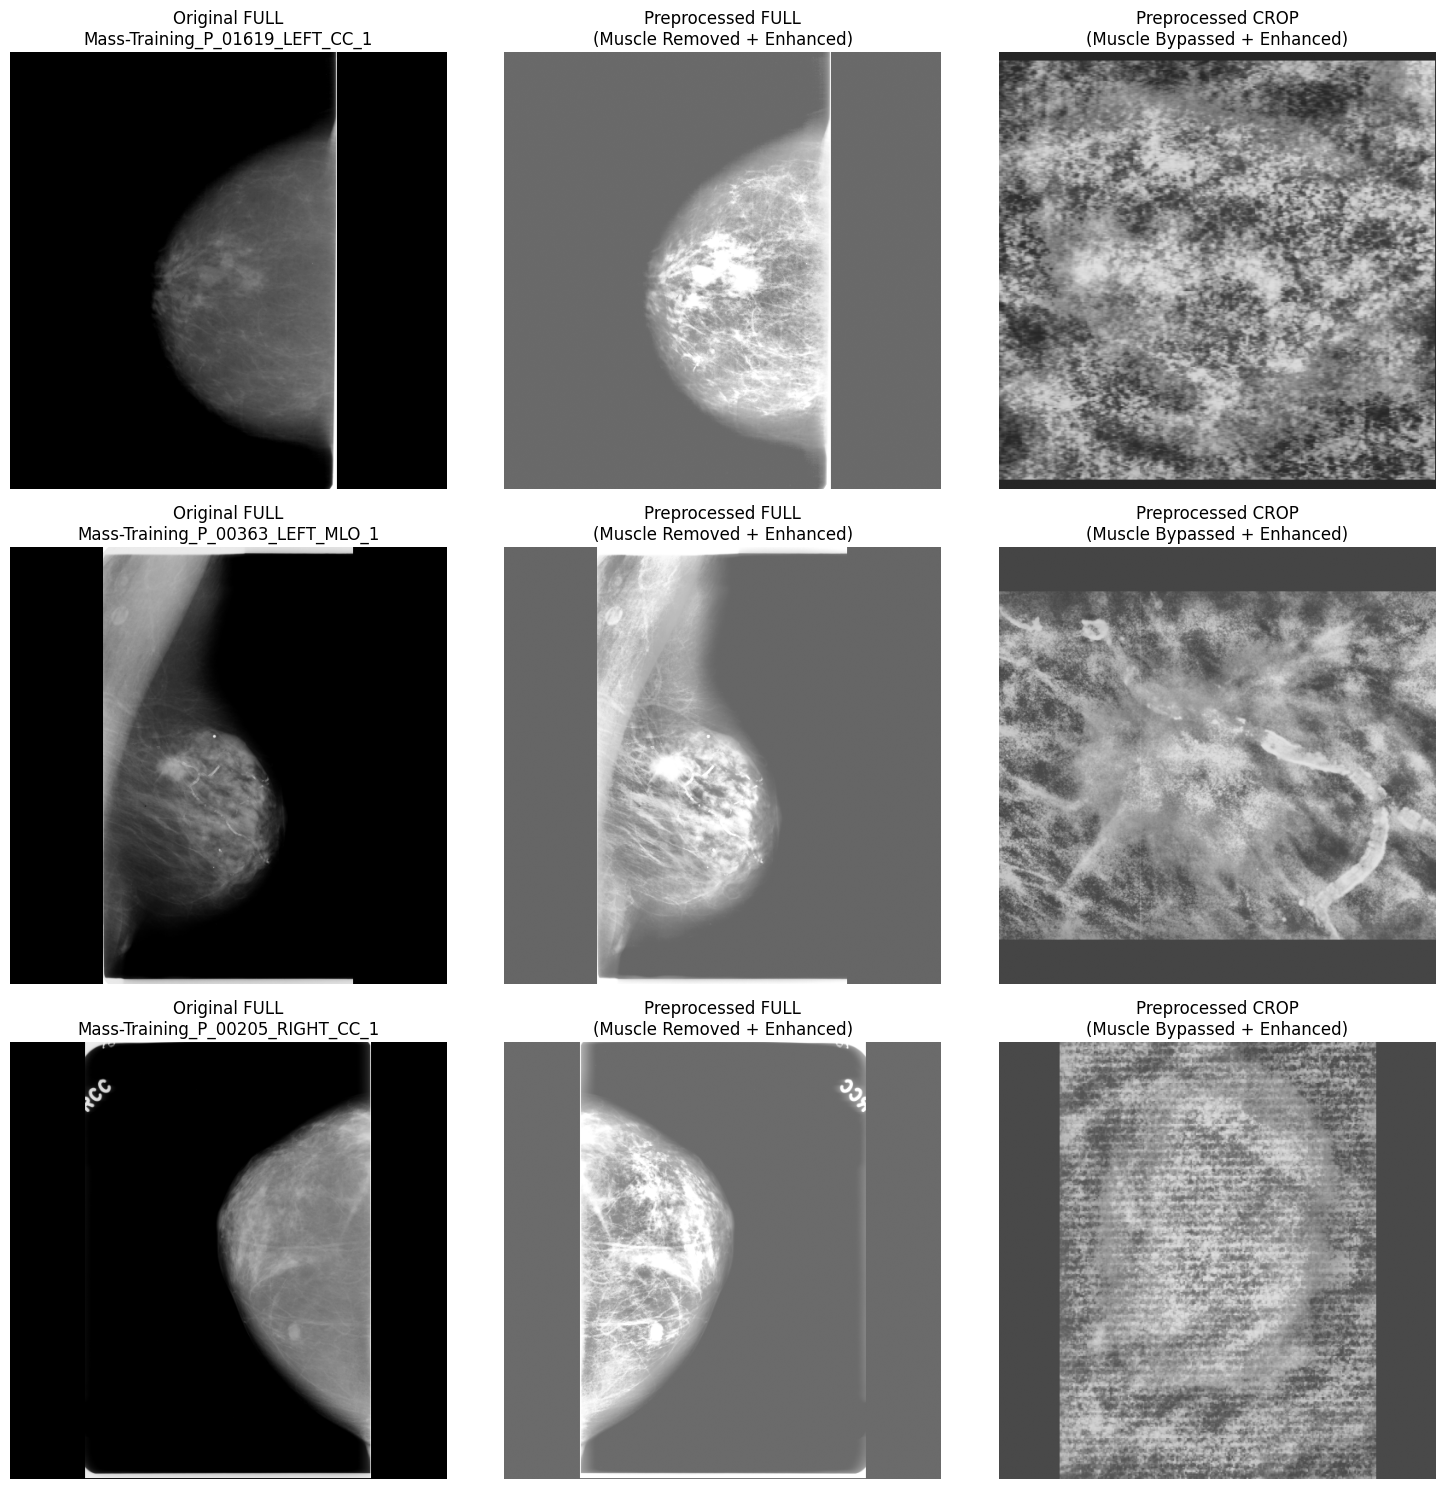

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from monai.transforms import MapTransform, Compose, EnsureChannelFirstd

# --- Configuration ---
DATA_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1" 
CSV_PATH = "CBIS_Master_Index_Clean.csv"      
RANDOM_SEED = 42

# ==============================================================================
# 1. Custom MONAI Dictionary Transforms
# ==============================================================================

class ConditionalFlipd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        patient_id = d[self.id_key]
        if "_RIGHT_" in patient_id:
            for key in self.keys:
                d[key] = cv2.flip(d[key], 1)
        return d


class PectoralRemovalMLOd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        patient_id = d[self.id_key]
        
        for key in self.keys:
            img = d[key]
            
            # AUTOMATIC BYPASS: CC views or images smaller than 1500px (Crops)
            if "_CC_" in patient_id or img.shape[0] < 1500:
                continue
                
            img_8u = (img / 256).astype(np.uint8)
            _, binary = cv2.threshold(img_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            
            h, w = binary.shape
            flood_mask = np.zeros((h + 2, w + 2), np.uint8)
            cv2.floodFill(binary, flood_mask, (0, 0), 255)
            
            pectoral_region = flood_mask[1:-1, 1:-1]
            d[key] = np.where(pectoral_region == 1, 0, img)
            
        return d


class CLAHE16Bitd(MapTransform):
    def __init__(self, keys, clip_limit=2.0, tile_grid_size=(8, 8)):
        super().__init__(keys)
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = self.clahe.apply(d[key].astype(np.uint16))
        return d


class ForegroundZScored(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key].astype(np.float32)
            mask = img > 0
            if mask.sum() > 0:
                img[mask] = (img[mask] - img[mask].mean()) / (img[mask].std() + 1e-8)
            d[key] = img
        return d


# ==============================================================================
# 2. Main Execution (Testing Both Full and Crop)
# ==============================================================================

def main():
    df = pd.read_csv(CSV_PATH)
    train_df = df[df['Patient_Split'] == 'Train'].sample(3, random_state=RANDOM_SEED)

    pipeline = Compose([
        ConditionalFlipd(keys=["image"]), 
        PectoralRemovalMLOd(keys=["image"]),     
        CLAHE16Bitd(keys=["image"]),             
        ForegroundZScored(keys=["image"]),       
        EnsureChannelFirstd(keys=["image"], channel_dim="no_channel")
    ])

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    
    for idx, (_, row) in enumerate(train_df.iterrows()):
        patient_id = row['PatientID']
        
        # Load BOTH images
        full_path = os.path.join(DATA_DIR, row['Full_Path'])
        crop_path = os.path.join(DATA_DIR, row['Crop_Path'])
        
        raw_full = cv2.imread(full_path, cv2.IMREAD_UNCHANGED)
        raw_crop = cv2.imread(crop_path, cv2.IMREAD_UNCHANGED)

        # Process FULL image
        full_dict = pipeline({"image": raw_full, "patient_id": patient_id})
        proc_full = full_dict["image"].squeeze()

        # Process CROP image
        crop_dict = pipeline({"image": raw_crop, "patient_id": patient_id})
        proc_crop = crop_dict["image"].squeeze()

        # Visualization
        raw_full_display = raw_full.astype(np.float32) / 65535.0

        axes[idx, 0].imshow(raw_full_display, cmap='gray')
        axes[idx, 0].set_title(f"Original FULL\n{patient_id}")
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(proc_full, cmap='gray', vmin=-3, vmax=3)
        axes[idx, 1].set_title("Preprocessed FULL\n(Muscle Removed + Enhanced)")
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(proc_crop, cmap='gray', vmin=-3, vmax=3)
        axes[idx, 2].set_title("Preprocessed CROP\n(Muscle Bypassed + Enhanced)")
        axes[idx, 2].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [8]:
!pip install segmentation-models-pytorch monai timm -q


In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from monai.transforms import Compose, EnsureChannelFirstd

class CBISDDSMDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df       = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        # Strictly 1-to-1 mapping. No dataset doubling.
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        patient_id   = row['PatientID']
        
        # Load ONLY the Full image and its corresponding Mask
        img_path   = os.path.join(self.data_dir, row['Full_Path'])
        roi_path   = os.path.join(self.data_dir, row['ROI_Path'])
        
        image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        roi   = cv2.imread(roi_path, cv2.IMREAD_UNCHANGED)

        if image is None:
            raise FileNotFoundError(f"Could not load image: {img_path}")
        if roi is None:
            raise FileNotFoundError(f"Could not load ROI: {roi_path}")

        roi = (roi > 0).astype(np.float32) # Binarize mask

        # Build MONAI Dictionary
        data_dict = {
            "image":      image,
            "roi":        roi,
            "patient_id": patient_id,
            "image_type": "FULL", # Hardcoded to FULL to bypass any crop logic
            "label":      np.array([row['Label']], dtype=np.float32)
        }

        # Apply Pipeline
        if self.transform:
            data_dict = self.transform(data_dict)

        img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
        roi_tensor   = torch.tensor(data_dict["roi"],   dtype=torch.float32)
        label_tensor = torch.tensor(data_dict["label"], dtype=torch.float32)

        return {"image": img_tensor, "roi": roi_tensor, "label": label_tensor}

# ==========================================================
# Quick Test to Prove it Works
# ==========================================================
if __name__ == "__main__":
    DATA_DIR = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1"
    df = pd.read_csv("CBIS_Master_Index_Clean.csv").head(2) # Take 2 patients
    print(f"Original CSV Rows: {len(df)}")
    
    test_transform = Compose([
        EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel")
    ])
    
    standard_dataset = CBISDDSMDataset(df, DATA_DIR, transform=test_transform)
    print(f"Standard Dataset Length: {len(standard_dataset)} (Strict 1-to-1 mapping)\n")
    
    # Iterate through the dataset
    for i in range(len(standard_dataset)):
        sample = standard_dataset[i]
        # We handle 'image_type' safely here in case it gets stripped by transformations
        print(f"Index {i}: {df.iloc[i]['PatientID']} | Image Shape: {sample['image'].shape} | Mask Shape: {sample['roi'].shape}")

Original CSV Rows: 2
Standard Dataset Length: 2 (Strict 1-to-1 mapping)

Index 0: Mass-Test_P_00016_LEFT_CC_1 | Image Shape: torch.Size([1, 512, 512]) | Mask Shape: torch.Size([1, 512, 512])
Index 1: Mass-Test_P_00016_LEFT_MLO_1 | Image Shape: torch.Size([1, 512, 512]) | Mask Shape: torch.Size([1, 512, 512])


/tmp/ipykernel_55/244554034.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
/tmp/ipykernel_55/244554034.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  roi_tensor   = torch.tensor(data_dict["roi"],   dtype=torch.float32)


In [11]:
!pip install segmentation-models-pytorch monai timm -q

In [12]:
# ==============================================================================
# EXP-05 — Staged Training (Phase 1: Seg Only -> Phase 2: MTL)
# ==============================================================================

import os
import cv2
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import monai
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from monai.transforms import MapTransform, Compose, EnsureChannelFirstd, RandFlipd, RandRotated
from monai.losses import TverskyLoss
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from tqdm import tqdm

# --- Configuration ---
DATA_DIR      = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1"
CSV_PATH      = "/kaggle/working/CBIS_Master_Index_Clean.csv"
BATCH_SIZE    = 4
MAX_EPOCHS    = 30
LEARNING_RATE = 1e-4
PATIENCE      = 10
RANDOM_SEED   = 42
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==============================================================================
# 1. Transforms
# ==============================================================================

class ConditionalFlipd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        if "RIGHT" in d[self.id_key].upper():
            for key in self.keys:
                d[key] = cv2.flip(d[key], 1)
        return d

class PectoralRemovalMLOd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        if "_CC" in d[self.id_key].upper() or d.get("image_type") == "CROP":
            return d
        for key in self.keys:
            img    = d[key]
            img_8u = (img / 256).astype(np.uint8)
            _, binary = cv2.threshold(img_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            h, w   = binary.shape
            flood_mask = np.zeros((h + 2, w + 2), np.uint8)
            cv2.floodFill(binary, flood_mask, (0, 0), 255)
            pectoral = flood_mask[1:-1, 1:-1]
            d[key]  = np.where(pectoral == 1, 0, img)
        return d

class CLAHE16Bitd(MapTransform):
    def __init__(self, keys, clip_limit=4.0, tile_grid_size=(8, 8)):
        super().__init__(keys)
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = self.clahe.apply(d[key].astype(np.uint16))
        return d

class ForegroundZScored(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img  = d[key].astype(np.float32)
            mask = img > 0
            if mask.sum() > 0:
                img[mask] = (img[mask] - img[mask].mean()) / (img[mask].std() + 1e-8)
            d[key] = img
        return d

def build_val_pipeline():
    return Compose([
        ConditionalFlipd(keys=["image", "roi"]),
        PectoralRemovalMLOd(keys=["image"]),
        CLAHE16Bitd(keys=["image"]),
        ForegroundZScored(keys=["image"]),
        EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel"),
    ])

def build_train_pipeline():
    return Compose([
        ConditionalFlipd(keys=["image", "roi"]),
        PectoralRemovalMLOd(keys=["image"]),
        CLAHE16Bitd(keys=["image"]),
        ForegroundZScored(keys=["image"]),
        EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel"),
        RandFlipd(keys=["image", "roi"], prob=0.5, spatial_axis=1),
        RandRotated(keys=["image", "roi"], range_x=15 * math.pi / 180, prob=0.5, mode=["bilinear", "nearest"], padding_mode="zeros"),
    ])

train_pipeline = build_train_pipeline()
val_pipeline   = build_val_pipeline()

# ==============================================================================
# 2. Dataset (Strictly 1-to-1, No Crops)
# ==============================================================================

class CBISDDSMDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df       = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        patient_id   = row['PatientID']

        img_path   = os.path.join(self.data_dir, row['Full_Path'])
        roi_path   = os.path.join(self.data_dir, row['ROI_Path'])

        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        roi = cv2.imread(roi_path, cv2.IMREAD_UNCHANGED)

        if img is None:
            raise FileNotFoundError(f"Could not load image: {img_path}")
        if roi is None:
            raise FileNotFoundError(f"Could not load ROI: {roi_path}")

        roi = (roi > 0).astype(np.float32)

        data_dict = {
            "image":      img,
            "roi":        roi,
            "patient_id": patient_id,
            "image_type": "FULL",
            "label":      np.array([row['Label']], dtype=np.float32),
        }

        if self.transform:
            data_dict = self.transform(data_dict)

        img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
        roi_tensor   = torch.tensor(data_dict["roi"],   dtype=torch.float32)
        label_tensor = torch.tensor(data_dict["label"], dtype=torch.float32)

        return {"image": img_tensor, "roi": roi_tensor, "label": label_tensor}

# ==============================================================================
# 3. Model & Custom Loss
# ==============================================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1      = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu     = nn.ReLU()
        self.fc2      = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        mx  = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        return self.sigmoid(avg + mx)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx  = torch.max(x,  dim=1, keepdim=True)[0]
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_planes):
        super().__init__()
        self.ca = ChannelAttention(in_planes)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class MTL_EfficientUNetPlusPlus(nn.Module):
    def __init__(self):
        super().__init__()
        self.smp_base = smp.UnetPlusPlus(
            encoder_name="tu-tf_efficientnet_b0",
            encoder_weights="imagenet",
            in_channels=1,
            classes=1,
            activation=None,
        )
        bottleneck_ch = self.smp_base.encoder.out_channels[-1]
        self.classification_branch = nn.Sequential(
            CBAM(in_planes=bottleneck_ch),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(bottleneck_ch, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        features    = self.smp_base.encoder(x)
        seg_mask    = self.smp_base.segmentation_head(self.smp_base.decoder(features))
        class_score = self.classification_branch(features[-1])
        return seg_mask, class_score

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(BinaryFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce_loss) 
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

# ==============================================================================
# 4. Helpers
# ==============================================================================

def calc_dice(pred_logits, target, smooth=1e-5):
    pred         = (torch.sigmoid(pred_logits) > 0.5).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union        = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return ((2. * intersection + smooth) / (union + smooth)).mean().item()

# ==============================================================================
# 5. Main
# ==============================================================================

def run_exp_05():
    set_seed(RANDOM_SEED)
    print(f"--- EXP-05: Staged Training on {DEVICE} ---")

    # Splits
    df       = pd.read_csv(CSV_PATH)
    train_df = df[df['Patient_Split'] == 'Train'].reset_index(drop=True)
    val_df   = df[df['Patient_Split'] == 'Val'].reset_index(drop=True)
    test_df  = df[df['Patient_Split'] == 'Test'].reset_index(drop=True)

    # Datasets & Loaders
    train_dataset = CBISDDSMDataset(train_df, DATA_DIR, train_pipeline)
    val_dataset   = CBISDDSMDataset(val_df,   DATA_DIR, val_pipeline)
    test_dataset  = CBISDDSMDataset(test_df,  DATA_DIR, val_pipeline)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    # Model
    model         = MTL_EfficientUNetPlusPlus().to(DEVICE)
    
    # --- CHANGED: Using Tversky for Segmentation ---
    criterion_seg = TverskyLoss(alpha=0.3, beta=0.7, sigmoid=True)
    criterion_cls = BinaryFocalLoss(alpha=0.25, gamma=2.0)
    
    optimizer     = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    best_val_dice     = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_auc': []}

    # INITIAL FREEZE: Phase 1 setup
    for param in model.classification_branch.parameters():
        param.requires_grad = False

    # Training
    for epoch in range(MAX_EPOCHS):
        
        # --- PHASE CONTROL ---
        if epoch == 0:
            print("\n--- PHASE 1: Segmentation Only (Epochs 1-10) ---")
            print("Classification branch is FROZEN.")
        elif epoch == 10:
            print("\n--- PHASE 2: Combined MTL (Epochs 11-30) ---")
            print("Unfreezing classification branch...")
            for param in model.classification_branch.parameters():
                param.requires_grad = True
            epochs_no_improve = 0  # reset patience for Phase 2

        model.train()
        train_loss = train_dice_loss = train_bce_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [Train]")
        for batch in loop:
            images = batch["image"].to(DEVICE)
            masks  = batch["roi"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            pred_masks, pred_logits = model(images)

            l_seg = criterion_seg(pred_masks, masks)
            l_cls = criterion_cls(pred_logits, labels)
            
            # --- PHASE LOSS LOGIC ---
            if epoch < 10:
                loss = l_seg
            else:
                loss = 0.7 * l_seg + 0.3 * l_cls

            loss.backward()
            optimizer.step()

            train_loss      += loss.item()
            train_dice_loss += l_seg.item()
            train_bce_loss  += l_cls.item()
            
            if epoch < 10:
                loop.set_postfix(Loss=f"{loss.item():.4f}", Tversky=f"{l_seg.item():.4f}", Focal="N/A")
            else:
                loop.set_postfix(Loss=f"{loss.item():.4f}", Tversky=f"{l_seg.item():.4f}", Focal=f"{l_cls.item():.4f}")

        # Validation
        model.eval()
        val_loss = val_dice_sum = 0.0
        all_labels, all_preds = [], []

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(DEVICE)
                masks  = batch["roi"].to(DEVICE)
                labels = batch["label"].to(DEVICE)

                pred_masks, pred_logits = model(images)
                l_seg = criterion_seg(pred_masks, masks)
                l_cls = criterion_cls(pred_logits, labels)

                if epoch < 10:
                    val_loss += l_seg.item()
                else:
                    val_loss += (0.7 * l_seg + 0.3 * l_cls).item()
                    
                val_dice_sum += calc_dice(pred_masks, masks)
                all_labels.extend(labels.cpu().numpy().flatten())
                all_preds.extend(torch.sigmoid(pred_logits).cpu().numpy().flatten())

        t_len      = len(train_loader)
        v_len      = len(val_loader)
        avg_t_loss = train_loss  / t_len
        avg_v_loss = val_loss    / v_len
        avg_v_dice = val_dice_sum / v_len

        try:
            val_auc = roc_auc_score(all_labels, all_preds)
        except ValueError:
            val_auc = 0.5

        history['train_loss'].append(avg_t_loss)
        history['val_loss'].append(avg_v_loss)
        history['val_dice'].append(avg_v_dice)
        history['val_auc'].append(val_auc)

        phase_lbl = "[P1]" if epoch < 10 else "[P2]"
        print(
            f"Ep {epoch+1:02d}/{MAX_EPOCHS} {phase_lbl} | "
            f"T_Loss: {avg_t_loss:.4f} | V_Loss: {avg_v_loss:.4f} | V_Dice: {avg_v_dice:.4f} | V_AUC: {val_auc:.4f}"
        )

        scheduler.step(avg_v_dice)

        if avg_v_dice > best_val_dice:
            best_val_dice     = avg_v_dice
            epochs_no_improve = 0
            torch.save(model.state_dict(), "best_model.pth")
            print("  [*] Best model saved.")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"\n--- Early stopping at epoch {epoch+1} ---")
                break

    # Test Evaluation
    print("\n--- Final Test Evaluation ---")
    model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
    model.eval()

    test_dice_sum = 0.0
    t_labels, t_preds, t_binary = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            images = batch["image"].to(DEVICE)
            masks  = batch["roi"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            pred_masks, pred_logits = model(images)
            test_dice_sum += calc_dice(pred_masks, masks)

            probs = torch.sigmoid(pred_logits).cpu().numpy().flatten()
            t_preds.extend(probs)
            t_binary.extend((probs > 0.5).astype(int))
            t_labels.extend(labels.cpu().numpy().flatten())

    final_dice = test_dice_sum / len(test_loader)
    final_auc  = roc_auc_score(t_labels, t_preds)
    final_acc  = accuracy_score(t_labels, t_binary)
    cm         = confusion_matrix(t_labels, t_binary)

    print(f"\nTest Dice:     {final_dice:.4f}  (Target: >0.75)")
    print(f"Test AUC:      {final_auc:.4f}  (Target: >0.85)")
    print(f"Test Accuracy: {final_acc:.4f}")
    print(f"Confusion Matrix:\n{cm}")

run_exp_05()

--- EXP-05: Staged Training on cuda ---


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



--- PHASE 1: Segmentation Only (Epochs 1-10) ---
Classification branch is FROZEN.


Epoch 1/30 [Train]:   0%|          | 0/237 [00:00<?, ?it/s]/tmp/ipykernel_55/3020026339.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
/tmp/ipykernel_55/3020026339.py:160: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  roi_tensor   = torch.tensor(data_dict["roi"],   dtype=torch.float32)
/tmp/ipykernel_55/3020026339.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
/tmp/ipykernel_55/3020026339.

...

Ep 27/30 [P2] | T_Loss: 0.2287 | V_Loss: 0.3010 | V_Dice: 0.5582 | V_AUC: 0.7421


Epoch 28/30 [Train]:   0%|          | 0/237 [00:00<?, ?it/s]/tmp/ipykernel_55/3020026339.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
/tmp/ipykernel_55/3020026339.py:160: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  roi_tensor   = torch.tensor(data_dict["roi"],   dtype=torch.float32)
/tmp/ipykernel_55/3020026339.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
/tmp/ipykernel_55/3020026339

Ep 28/30 [P2] | T_Loss: 0.2205 | V_Loss: 0.3001 | V_Dice: 0.5602 | V_AUC: 0.7115

--- Early stopping at epoch 28 ---

--- Final Test Evaluation ---


/tmp/ipykernel_55/3020026339.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
/tmp/ipykernel_55/3020026339.py:160: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  roi_tensor   = torch.tensor(data_dict["roi"],   dtype=torch.float32)
/tmp/ipykernel_55/3020026339.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor   = torch.tensor(data_dict["image"], dtype=torch.float32)
/tmp/ipykernel_55/3020026339.py:160: UserWarning: To copy construct from a tensor, it is


Test Dice:     0.5245  (Target: >0.75)
Test AUC:      0.7805  (Target: >0.85)
Test Accuracy: 0.6973
Confusion Matrix:
[[93 28]
 [51 89]]


In [13]:
!pip install grad-cam segmentation-models-pytorch monai timm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.3 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Using Device: cuda
Model loaded.

--- Analyzing Mass Cases (390 samples) ---
Mass-Training_P_00487_RIGHT_CC_1 | GT: Benign | Pred: 0.42✓ | MGT: 0.006
Mass-Test_P_00391_RIGHT_MLO_1 | GT: Benign | Pred: 0.36✓ | MGT: 0.000
Mass-Training_P_00330_LEFT_CC_1 | GT: Benign | Pred: 0.44✓ | MGT: 0.008
Mass-Training_P_01048_RIGHT_CC_1 | GT: Benign | Pred: 0.45✓ | MGT: 0.015
Mass-Training_P_00442_RIGHT_CC_1 | GT: Benign | Pred: 0.43✓ | MGT: 0.025
Mass-Test_P_01558_RIGHT_MLO_1 | GT: Malignant | Pred: 0.68✓ | MGT: 0.015
Mass-Training_P_01427_LEFT_MLO_1 | GT: Malignant | Pred: 0.66✓ | MGT: 0.022
Mass-Training_P_01144_LEFT_MLO_1 | GT: Malignant | Pred: 0.53✓ | MGT: 0.007
Mass-Training_P_00543_RIGHT_CC_1 | GT: Malignant | Pred: 0.53✓ | MGT: 0.000
Mass-Training_P_00241_RIGHT_MLO_1 | GT: Malignant | Pred: 0.53✓ | MGT: 0.006


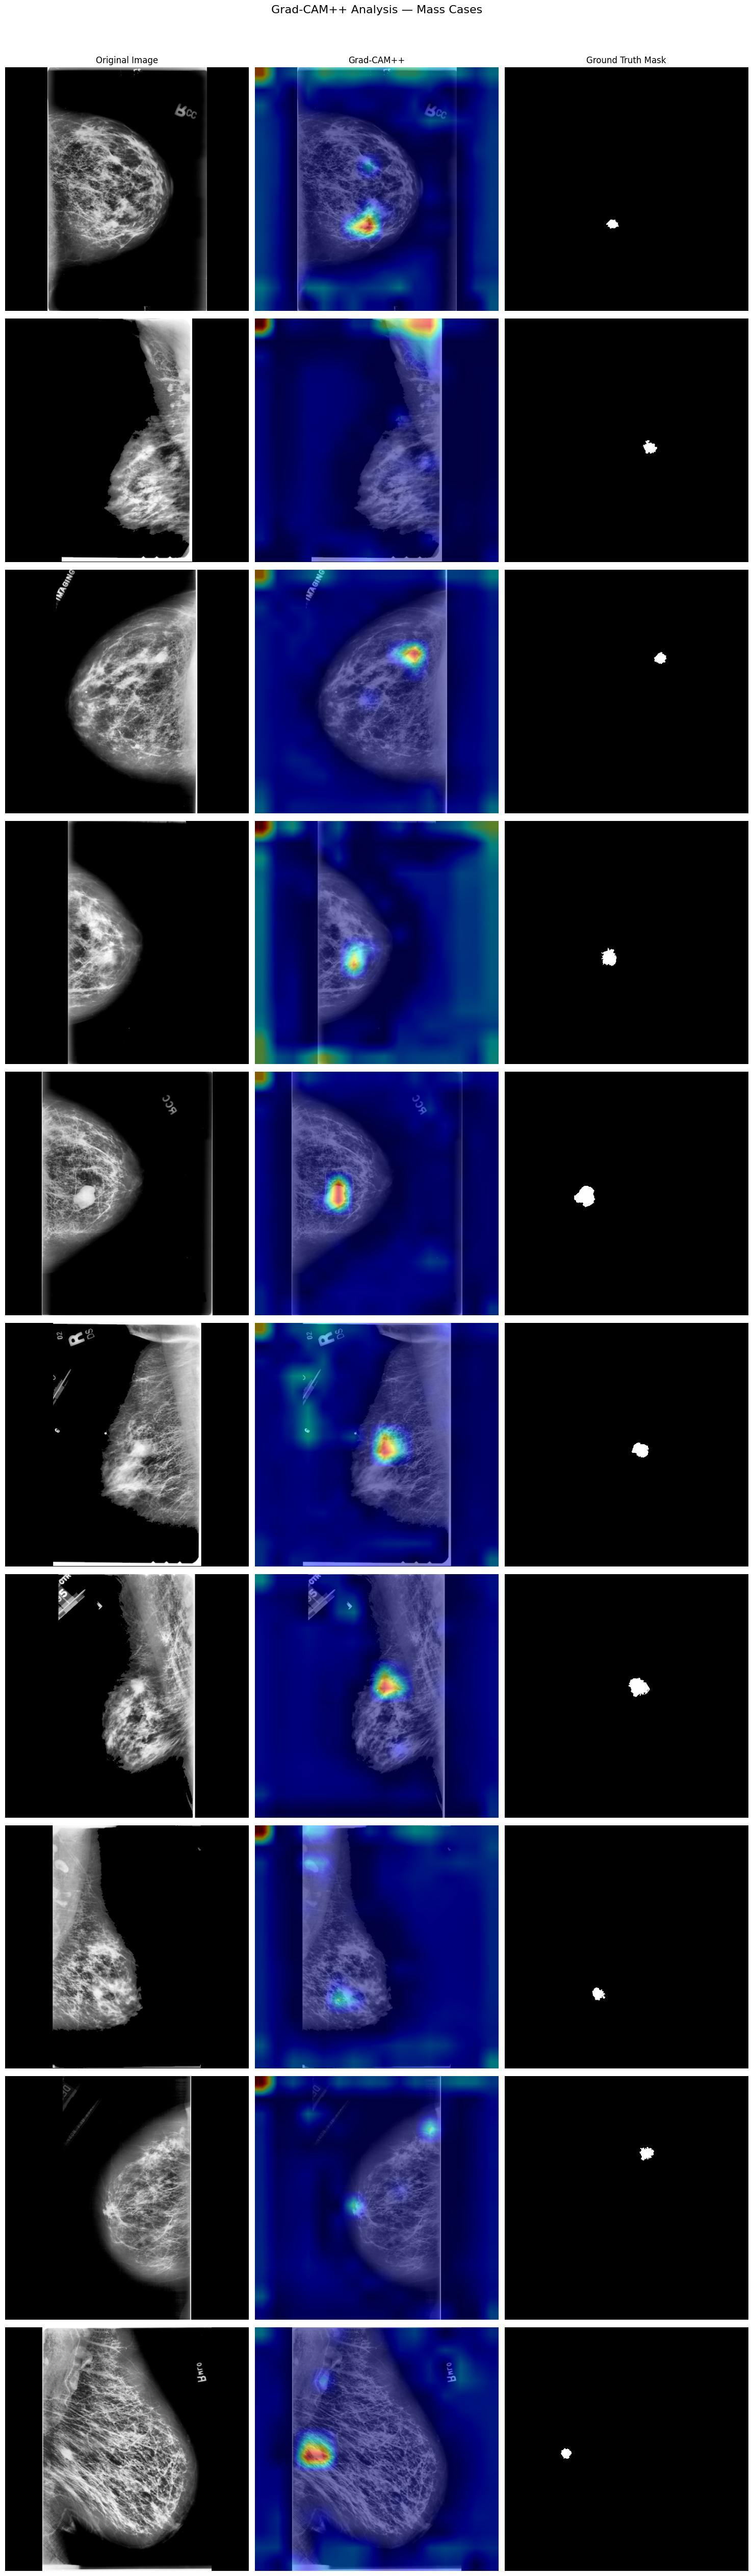

Saved: /kaggle/working/gradcam_outputs/gradcam_mass_cases.png

========== EXP-06 SUMMARY ==========
Avg MGT Score: 0.0104
Target MGT > 0.80


In [14]:
# ==============================================================================
# EXP-06 — Grad-CAM Analysis
# ==============================================================================

import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from monai.transforms import MapTransform, Compose, EnsureChannelFirstd
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import roc_auc_score

# --- Configuration ---
DATA_DIR    = "/kaggle/input/datasets/abdelrahmanelmugh/cbis-ddsm-512-full1-wm/CBIS-DDSM-512-FULL1/CBIS-DDSM-512-FULL1"
CSV_PATH    = "/kaggle/working/CBIS_Master_Index_Clean.csv"
MODEL_PATH  = "/kaggle/working/best_model.pth"
OUTPUT_DIR  = "/kaggle/working/gradcam_outputs"
RANDOM_SEED = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==============================================================================
# 1. Preprocessing (Strictly Full Images)
# ==============================================================================

class ConditionalFlipd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        if "RIGHT" in d[self.id_key].upper():
            for key in self.keys:
                d[key] = cv2.flip(d[key], 1)
        return d

class PectoralRemovalMLOd(MapTransform):
    def __init__(self, keys, id_key="patient_id"):
        super().__init__(keys)
        self.id_key = id_key

    def __call__(self, data):
        d = dict(data)
        if "_CC" in d[self.id_key].upper():
            return d
        for key in self.keys:
            img = d[key]
            img_8u = (img / 256).astype(np.uint8)
            _, binary = cv2.threshold(img_8u, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            h, w = binary.shape
            flood_mask = np.zeros((h + 2, w + 2), np.uint8)
            cv2.floodFill(binary, flood_mask, (0, 0), 255)
            pectoral_mask = flood_mask[1:-1, 1:-1]
            d[key] = np.where(pectoral_mask == 1, 0, img)
        return d

class CLAHE16Bitd(MapTransform):
    def __init__(self, keys, clip_limit=4.0, tile_grid_size=(8, 8)):
        super().__init__(keys)
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = self.clahe.apply(d[key].astype(np.uint16))
        return d

class ForegroundZScored(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            img = d[key].astype(np.float32)
            mask = img > 0
            if mask.sum() > 0:
                img[mask] = (img[mask] - img[mask].mean()) / (img[mask].std() + 1e-8)
            d[key] = img
        return d

def build_val_pipeline():
    return Compose([
        ConditionalFlipd(keys=["image", "roi"]),
        PectoralRemovalMLOd(keys=["image"]),
        CLAHE16Bitd(keys=["image"]),
        ForegroundZScored(keys=["image"]),
        EnsureChannelFirstd(keys=["image", "roi"], channel_dim="no_channel"),
    ])

# ==============================================================================
# 2. Model 
# ==============================================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1      = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu     = nn.ReLU()
        self.fc2      = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        mx  = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        return self.sigmoid(avg + mx)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx  = torch.max(x,  dim=1, keepdim=True)[0]
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, in_planes):
        super().__init__()
        self.ca = ChannelAttention(in_planes)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class MTL_EfficientUNetPlusPlus(nn.Module):
    def __init__(self):
        super().__init__()
        self.smp_base = smp.UnetPlusPlus(
            encoder_name="tu-tf_efficientnet_b0",
            encoder_weights=None,
            in_channels=1,
            classes=1,
            activation=None,
        )
        bottleneck_ch = self.smp_base.encoder.out_channels[-1]
        self.classification_branch = nn.Sequential(
            CBAM(in_planes=bottleneck_ch),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(bottleneck_ch, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        features    = self.smp_base.encoder(x)
        seg_mask    = self.smp_base.segmentation_head(self.smp_base.decoder(features))
        class_score = self.classification_branch(features[-1])
        return seg_mask, class_score

class ClassificationWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        _, class_score = self.model(x)
        return class_score

# ==============================================================================
# 3. Helpers
# ==============================================================================

def compute_mgt(heatmap, gt_mask):
    threshold      = np.percentile(heatmap, 80)
    binarized_heat = (heatmap >= threshold).astype(np.float32)
    gt_bin         = (gt_mask > 0).astype(np.float32)
    intersection   = np.logical_and(binarized_heat, gt_bin).sum()
    union          = np.logical_or(binarized_heat, gt_bin).sum()
    return float(intersection / (union + 1e-8))

def norm_for_display(img_tensor):
    img      = img_tensor.squeeze().cpu().numpy()
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return np.stack([img_norm] * 3, axis=-1).astype(np.float32)

def preprocess_sample(img_raw, roi_raw, patient_id, pipeline):
    roi_binary = (roi_raw > 0).astype(np.float32)
    data_dict  = {
        "image":      img_raw,
        "roi":        roi_binary,
        "patient_id": patient_id,
    }
    processed  = pipeline(data_dict)
    img_tensor = processed["image"].clone().detach().to(torch.float32)
    roi_np     = processed["roi"].squeeze().numpy()
    return img_tensor, roi_np

def run_gradcam_on_sample(model, cam, img_tensor, device):
    img_input = img_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        pred_mask_logits, pred_score_logits = model(img_input)
        pred_score = torch.sigmoid(pred_score_logits).item()
    grayscale_cam = cam(input_tensor=img_input, targets=None)[0]
    return pred_score, grayscale_cam

# ==============================================================================
# 4. Grad-CAM Analysis
# ==============================================================================

def analyze_group(group_df, model, cam, pipeline, device, n_samples=5):
    
    sample_df = pd.concat([
        group_df[group_df['Label'] == 0].sample(min(n_samples, len(group_df[group_df['Label'] == 0])), random_state=RANDOM_SEED),
        group_df[group_df['Label'] == 1].sample(min(n_samples, len(group_df[group_df['Label'] == 1])), random_state=RANDOM_SEED),
    ]).reset_index(drop=True)

    n_rows  = len(sample_df)
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    fig.suptitle(f"Grad-CAM++ Analysis — Mass Cases", fontsize=16, y=1.01)

    for col, title in enumerate(["Original Image", "Grad-CAM++", "Ground Truth Mask"]):
        axes[0, col].set_title(title, fontsize=12)

    mgt_scores = []

    for idx, (_, row) in enumerate(sample_df.iterrows()):
        patient_id = row['PatientID']
        gt_label   = "Malignant" if row['Label'] == 1 else "Benign"

        full_raw = cv2.imread(os.path.join(DATA_DIR, row['Full_Path']), cv2.IMREAD_UNCHANGED)
        roi_raw  = cv2.imread(os.path.join(DATA_DIR, row['ROI_Path']),  cv2.IMREAD_UNCHANGED)

        if full_raw is None or roi_raw is None:
            print(f"WARNING: Could not load {patient_id}, skipping.")
            continue

        full_tensor, roi_np = preprocess_sample(full_raw, roi_raw, patient_id, pipeline)
        full_score, full_cam = run_gradcam_on_sample(model, cam, full_tensor, device)

        mgt_full = compute_mgt(full_cam, roi_np)
        mgt_scores.append(mgt_full)

        full_correct = "✓" if (full_score > 0.5) == bool(row['Label']) else "✗"

        axes[idx, 0].imshow(norm_for_display(full_tensor), cmap='gray')
        axes[idx, 0].set_ylabel(f"GT: {gt_label}\n{patient_id}", fontsize=8)
        axes[idx, 0].axis('off')

        full_cam_img = show_cam_on_image(norm_for_display(full_tensor), full_cam, use_rgb=True, colormap=cv2.COLORMAP_JET)
        axes[idx, 1].imshow(full_cam_img)
        axes[idx, 1].set_xlabel(f"Pred: {'Mal' if full_score>0.5 else 'Ben'} {full_correct} ({full_score:.2f})\nMGT: {mgt_full:.3f}", fontsize=8)
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(roi_np, cmap='gray')
        axes[idx, 2].axis('off')

        print(f"{patient_id} | GT: {gt_label} | Pred: {full_score:.2f}{full_correct} | MGT: {mgt_full:.3f}")

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"gradcam_mass_cases.png")
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    return mgt_scores

# ==============================================================================
# 5. Main
# ==============================================================================

def main():
    set_seed(RANDOM_SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using Device: {device}")

    model = MTL_EfficientUNetPlusPlus().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded.")

    cam_model = ClassificationWrapper(model)
    # --- CHANGED: Target layer pointed to the penultimate block ---
    target_layer = [model.smp_base.encoder.model.blocks[-2][-1]]
    
    cam = GradCAMPlusPlus(model=cam_model, target_layers=target_layer)

    df       = pd.read_csv(CSV_PATH)
    eval_df  = df[df['Patient_Split'].isin(['Val', 'Test'])].copy()

    pipeline = build_val_pipeline()

    print(f"\n--- Analyzing Mass Cases ({len(eval_df)} samples) ---")
    mgt_mass = analyze_group(eval_df, model, cam, pipeline, device)

    print("\n========== EXP-06 SUMMARY ==========")
    print(f"Avg MGT Score: {np.mean(mgt_mass):.4f}")
    print(f"Target MGT > 0.80")
    print("======================================")

if __name__ == "__main__":
    main()